# Ejercicio 5: Analisis espacial

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy import ndimage
import geopandas as gpd
import folium

sys.path.insert(0, "..")

from src.config import LAGOS
from src.download import DATA_RAW
from src.indices import compute_indices
from src.mask import get_water_mask, GEOJSON_DIR

plt.rcParams["figure.dpi"] = 100

PIXELES_EROSION = 2  

def water_mask_erosionada(water_mask: np.ndarray, iterations: int = PIXELES_EROSION) -> np.ndarray:
    """Encoge la mascara de agua hacia adentro para excluir pixeles mixtos de la orilla."""
    return ndimage.binary_erosion(water_mask, iterations=iterations)


### 5.1 Mapa de distribución de cianobacteria por lago (matplotlib)

In [ ]:
def mapear_cianobacteria(lago: str, fecha: str):
    tif_path = DATA_RAW / lago / f"{fecha}.tif"

    idx = compute_indices(lago, fecha)
    water_mask = water_mask_erosionada(get_water_mask(lago, tif_path, idx["ndwi"]))
    array_enmascarado = np.where(water_mask, idx["cianobacteria"], np.nan)

    with rasterio.open(tif_path) as src:
        bounds = src.bounds 

    vmin, vmax = np.nanpercentile(array_enmascarado, [2, 98])

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(array_enmascarado, cmap='viridis', vmin=vmin, vmax=vmax,
                    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    plt.colorbar(im, ax=ax, label="Indice de cianobacteria")
    ax.set_title(f"Cianobacteria — {lago.capitalize()} ({fecha})")

mapear_cianobacteria("atitlan", LAGOS["atitlan"]["fechas"][0])
mapear_cianobacteria("amatitlan", LAGOS["amatitlan"]["fechas"][0])


### 5.1b Mapa interactivo (folium)

In [ ]:
def mapa_interactivo_cianobacteria(lago: str, fecha: str) -> folium.Map:
    """Construye un folium.Map con el raster de cianobacteria superpuesto (ImageOverlay)."""
    tif_path = DATA_RAW / lago / f"{fecha}.tif"

    idx = compute_indices(lago, fecha)
    water_mask = water_mask_erosionada(get_water_mask(lago, tif_path, idx["ndwi"]))
    array_enmascarado = np.where(water_mask, idx["cianobacteria"], np.nan).astype(np.float32)

    with rasterio.open(tif_path) as src:
        dst_transform, width, height = calculate_default_transform(
            src.crs, "EPSG:4326", src.width, src.height, *src.bounds
        )
        array_4326 = np.full((height, width), np.nan, dtype=np.float32)
        reproject(
            source=array_enmascarado,
            destination=array_4326,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs="EPSG:4326",
            resampling=Resampling.nearest,
        )

    left, bottom = dst_transform * (0, height)
    right, top = dst_transform * (width, 0)

    valid = ~np.isnan(array_4326)
    vmin, vmax = np.nanpercentile(array_4326, [2, 98])
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    rgba = plt.cm.YlOrRd(norm(array_4326))
    rgba[..., 3] = np.where(valid, 0.75, 0.0)

    centro_lat = (bottom + top) / 2
    centro_lon = (left + right) / 2
    m = folium.Map(location=[centro_lat, centro_lon], zoom_start=13, tiles="OpenStreetMap")

    folium.raster_layers.ImageOverlay(
        image=rgba,
        bounds=[[bottom, left], [top, right]],
        opacity=0.85,
        name=f"Cianobacteria {fecha}",
    ).add_to(m)

    geojson_path = GEOJSON_DIR / f"{lago}.geojson"
    if geojson_path.exists():
        gdf = gpd.read_file(geojson_path).to_crs("EPSG:4326")
        folium.GeoJson(
            gdf,
            name="Limite del lago",
            style_function=lambda x: {"color": "#00008b", "weight": 2, "fillOpacity": 0},
        ).add_to(m)

    folium.LayerControl().add_to(m)
    return m


mapa_interactivo_cianobacteria("atitlan", LAGOS["atitlan"]["fechas"][0])


### 5.2 Mapas comparativos entre fechas (por lago)

In [ ]:
def _array_cianobacteria(lago: str, fecha: str) -> np.ndarray:
    tif_path = DATA_RAW / lago / f"{fecha}.tif"
    idx = compute_indices(lago, fecha)
    water_mask = water_mask_erosionada(get_water_mask(lago, tif_path, idx["ndwi"]))
    return np.where(water_mask, idx["cianobacteria"], np.nan)


def comparar_fechas(lago: str, fechas: list[str]):
    """Grafica un grid de mapas de cianobacteria (uno por fecha) con la misma escala de color."""
    arrays = [_array_cianobacteria(lago, fecha) for fecha in fechas]

    todos_los_valores = np.concatenate([a[~np.isnan(a)] for a in arrays])
    vmin, vmax = np.nanpercentile(todos_los_valores, [2, 98])

    fig, axes = plt.subplots(1, len(fechas), figsize=(4.5 * len(fechas), 5))
    if len(fechas) == 1:
        axes = [axes]

    im = None
    for ax, fecha, array in zip(axes, fechas, arrays):
        im = ax.imshow(array, cmap="YlOrRd", vmin=vmin, vmax=vmax)
        ax.set_title(fecha)
        ax.axis("off")

    fig.suptitle(f"Cianobacteria — {lago.capitalize()}")
    fig.colorbar(im, ax=axes, shrink=0.8, label="Indice de cianobacteria")
    plt.show()


fechas_atitlan = LAGOS["atitlan"]["fechas"][:4]
comparar_fechas("atitlan", fechas_atitlan)

fechas_amatitlan = LAGOS["amatitlan"]["fechas"][:4]
comparar_fechas("amatitlan", fechas_amatitlan)


### 5.3 Patrones espaciales: zonas persistentes y mapas de diferencia

C:\Users\sofia\AppData\Local\Temp\ipykernel_13028\3706076011.py:5: RuntimeWarning: Mean of empty slice
  promedio_temporal = np.nanmean(stack, axis=0)


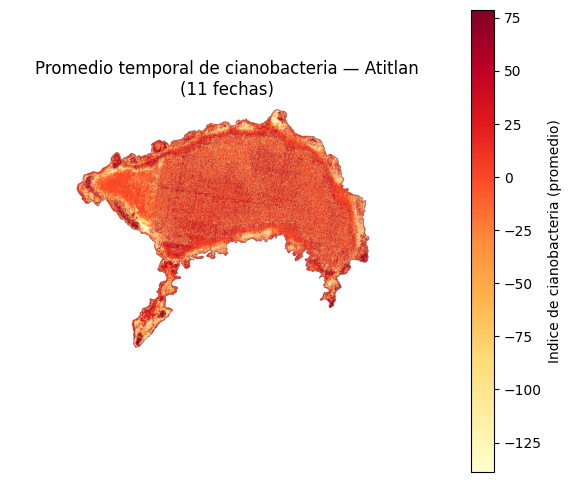

C:\Users\sofia\AppData\Local\Temp\ipykernel_13028\3706076011.py:5: RuntimeWarning: Mean of empty slice
  promedio_temporal = np.nanmean(stack, axis=0)


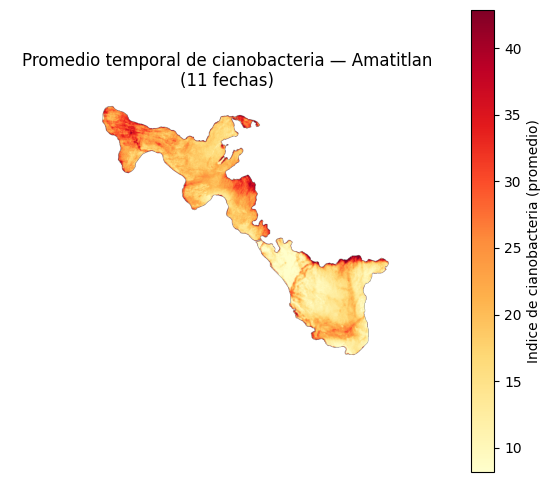

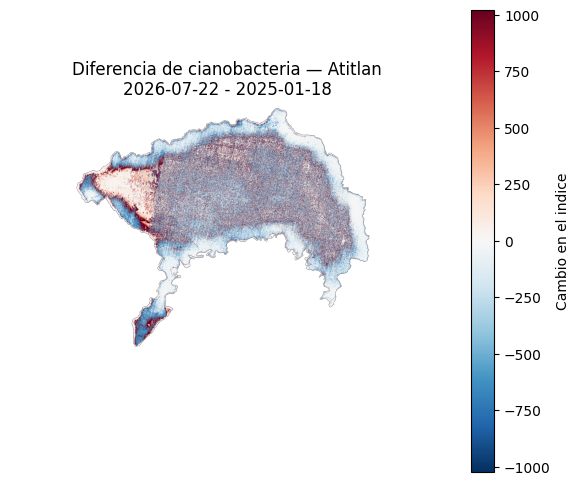

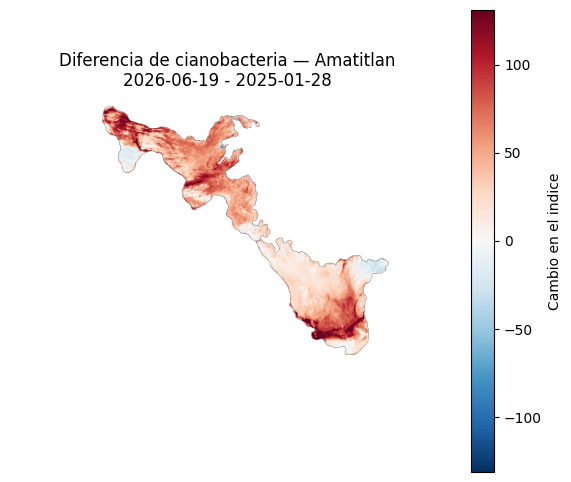

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(917, 1360), dtype=float32)

In [5]:
def zonas_persistentes(lago: str, fechas: list[str]):
    """Promedia el indice de cianobacteria pixel a pixel a lo largo de varias fechas."""
    arrays = [_array_cianobacteria(lago, fecha) for fecha in fechas]
    stack = np.stack(arrays)
    promedio_temporal = np.nanmean(stack, axis=0)

    vmin, vmax = np.nanpercentile(promedio_temporal, [2, 98])

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(promedio_temporal, cmap="YlOrRd", vmin=vmin, vmax=vmax)
    ax.set_title(f"Promedio temporal de cianobacteria — {lago.capitalize()}\n({len(fechas)} fechas)")
    ax.axis("off")
    fig.colorbar(im, ax=ax, label="Indice de cianobacteria (promedio)")
    plt.show()
    return promedio_temporal


def mapa_diferencia(lago: str, fecha_a: str, fecha_b: str):
    """Resta el indice de cianobacteria entre dos fechas para ver cambios."""
    array_a = _array_cianobacteria(lago, fecha_a)
    array_b = _array_cianobacteria(lago, fecha_b)
    diferencia = array_b - array_a


    limite = np.nanpercentile(np.abs(diferencia), 98)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(diferencia, cmap="RdBu_r", vmin=-limite, vmax=limite)
    ax.set_title(f"Diferencia de cianobacteria — {lago.capitalize()}\n{fecha_b} - {fecha_a}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, label="Cambio en el indice")
    plt.show()
    return diferencia


zonas_persistentes("atitlan", LAGOS["atitlan"]["fechas"])
zonas_persistentes("amatitlan", LAGOS["amatitlan"]["fechas"])

mapa_diferencia("atitlan", LAGOS["atitlan"]["fechas"][0], LAGOS["atitlan"]["fechas"][-1])
mapa_diferencia("amatitlan", LAGOS["amatitlan"]["fechas"][0], LAGOS["amatitlan"]["fechas"][-1])


**Interpretación de los patrones espaciales**

**Amatitlán:** Al promediar las 11 fechas analizadas, la contaminación por cianobacteria no se reparte de forma pareja dentro del lago: la zona que consistentemente sale peor es el brazo angosto del norte, el canal que conecta la parte alta del lago con la cuenca principal. Ahí los niveles promedio son los más altos de todo el cuerpo de agua. La cuenca sur, más abierta y grande, se mantiene en niveles notablemente más bajos casi siempre. Esto tiene sentido: las zonas angostas con poca circulación de agua acumulan más algas que las zonas abiertas donde el agua se mezcla y se renueva más fácilmente.

Al comparar fechas puntuales se ve además que la intensidad cambia bastante de una visita a otra: el 28 de abril de 2025 muestra una floración mucho más extendida (buena parte del canal norte y de la orilla este de la cuenca sur en rojo intenso) que apenas dos semanas antes, el 15 de abril. Es decir, sobre una contaminación de fondo que nunca desaparece, hay picos puntuales de floración más fuerte — probablemente ligados a lluvias que arrastran nutrientes desde la cuenca urbana, o a periodos de aguas más quietas.

**Atitlán** En la mayoría de las fechas, el lago se mantiene en niveles base, sin señal de floración, con una ligera elevación cerca de las orillas (normal en cualquier lago: ahí se mezcla la señal del agua con la de la tierra de al lado). Sin embargo, en varias fechas de los meses más fríos y secos del año (enero, noviembre, diciembre, febrero) el índice se dispara a valores muy negativos en todo el lago a la vez, no en manchas localizadas como se esperaría de una floración real. Ese patrón, un cambio uniforme de todo el cuerpo de agua en vez de zonas puntuales, es más compatible con que el método de cálculo no esté funcionando bien para este lago en esos meses (agua muy clara y profunda, distinta luz solar), que con un fenómeno biológico real (no existe una "floración negativa"). 

En conjunto, los mapas espaciales confirman lo que ya se veía en el análisis temporal: Amatitlán tiene un problema de cianobacteria activo, concentrado sobre todo en su brazo norte, mientras que Atitlán no muestra evidencia de floración real en el período estudiado.